In [1]:
# ============================================================
# Notebook 05 — Prophet Modelling
# Baseline V1: Default settings, yearly seasonality
# Reference: Taylor & Letham (2018)
# Implementation: Meta Prophet library
# Author: Nihaar Raut | 001309432
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import logging
logging.getLogger('prophet').setLevel(logging.ERROR)
import warnings
warnings.filterwarnings('ignore')

PROCESSED = Path('../data/processed')
FIGURES = Path('../outputs/figures')

# Load all four series
ndvi_amazon_train = pd.read_csv(PROCESSED / 'ndvi_amazon_train.csv', parse_dates=['date'])
ndvi_amazon_test = pd.read_csv(PROCESSED / 'ndvi_amazon_test.csv', parse_dates=['date'])

ndvi_sahel_train = pd.read_csv(PROCESSED / 'ndvi_sahel_train.csv', parse_dates=['date'])
ndvi_sahel_test = pd.read_csv(PROCESSED / 'ndvi_sahel_test.csv', parse_dates=['date'])

sst_atlantic_train = pd.read_csv(PROCESSED / 'sst_atlantic_train.csv', parse_dates=['date'])
sst_atlantic_test = pd.read_csv(PROCESSED / 'sst_atlantic_test.csv', parse_dates=['date'])

sst_indian_train = pd.read_csv(PROCESSED / 'sst_indian_train.csv', parse_dates=['date'])
sst_indian_test = pd.read_csv(PROCESSED / 'sst_indian_test.csv', parse_dates=['date'])

print("All series loaded successfully")

Importing plotly failed. Interactive plots will not work.


All series loaded successfully


03:07:12 - cmdstanpy - INFO - Chain [1] start processing
03:07:12 - cmdstanpy - INFO - Chain [1] done processing


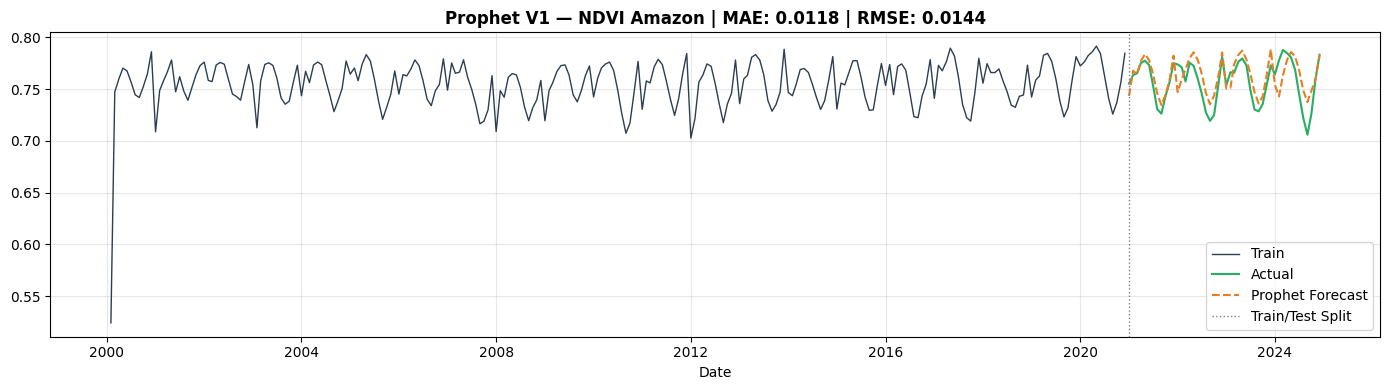

03:07:13 - cmdstanpy - INFO - Chain [1] start processing
03:07:13 - cmdstanpy - INFO - Chain [1] done processing


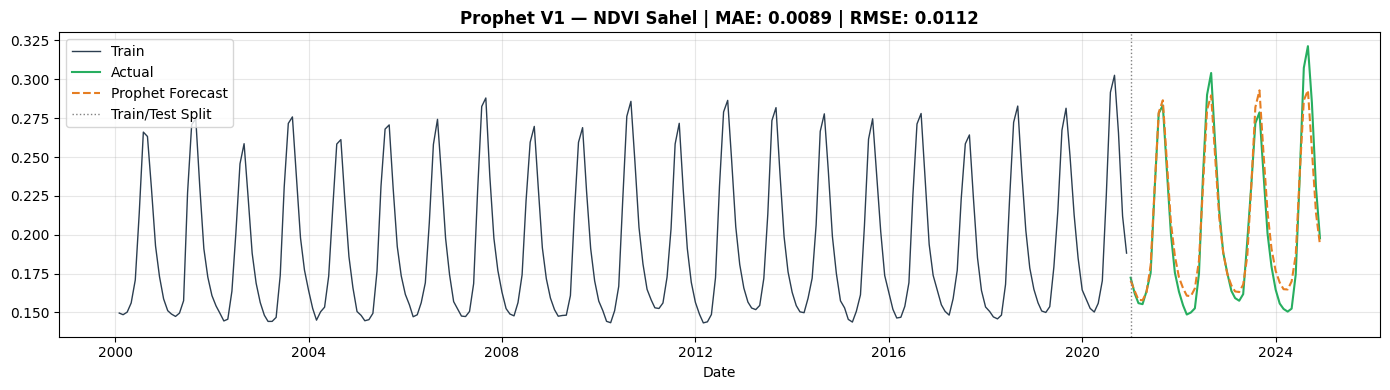

03:07:13 - cmdstanpy - INFO - Chain [1] start processing
03:07:13 - cmdstanpy - INFO - Chain [1] done processing


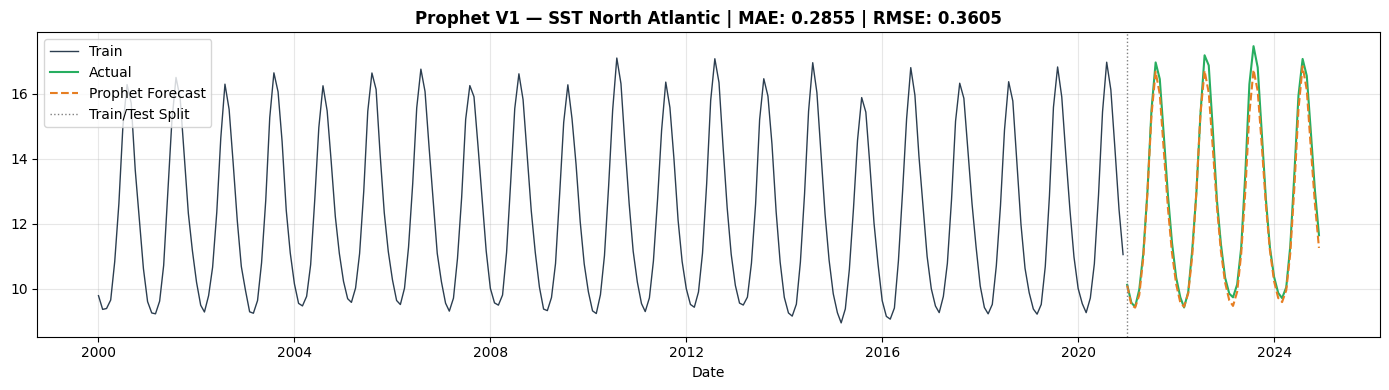

03:07:14 - cmdstanpy - INFO - Chain [1] start processing
03:07:14 - cmdstanpy - INFO - Chain [1] done processing


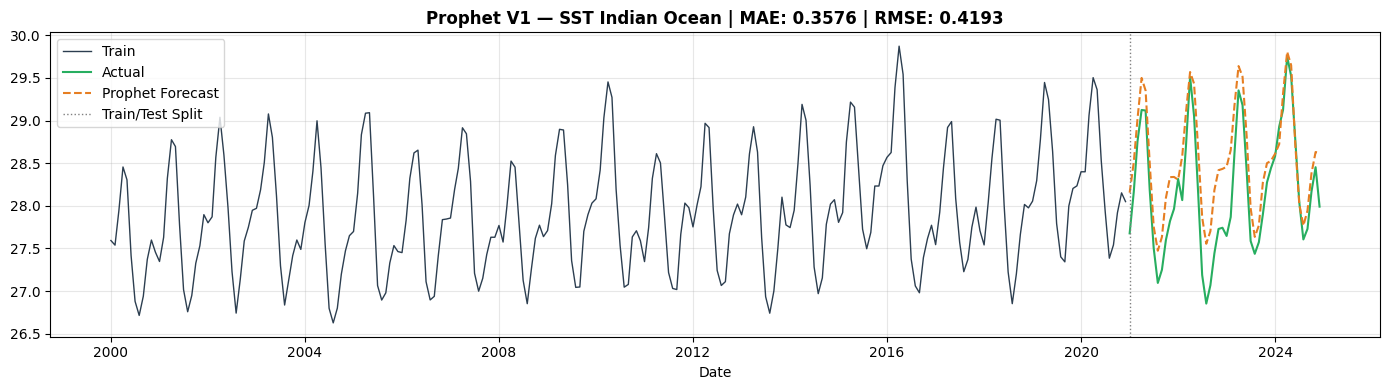


=== Prophet V1 Baseline Results ===
            series    MAE   RMSE
       NDVI Amazon 0.0118 0.0144
        NDVI Sahel 0.0089 0.0112
SST North Atlantic 0.2855 0.3605
  SST Indian Ocean 0.3576 0.4193


In [2]:
# ============================================================
# Prophet V1 — Baseline, default settings, yearly seasonality
# Prophet requires columns named 'ds' (date) and 'y' (value)
# Additive mode, yearly seasonality enabled
# ============================================================

def run_prophet(train, test, value_col, series_name):
    # Prophet requires ds/y format
    train_prophet = train[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'})
    test_prophet = test[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'})
    
    # Fit model
    model = Prophet(
        seasonality_mode='additive',
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )
    model.fit(train_prophet)
    
    # Forecast
    future = model.make_future_dataframe(periods=len(test), freq='MS')
    forecast = model.predict(future)
    forecast_test = forecast.tail(len(test))['yhat'].values
    actual = test[value_col].values
    
    # Metrics
    mae = mean_absolute_error(actual, forecast_test)
    rmse = np.sqrt(mean_squared_error(actual, forecast_test))
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['date'], train[value_col],
            color='#2c3e50', linewidth=1, label='Train')
    ax.plot(test['date'], actual,
            color='#27ae60', linewidth=1.5, label='Actual')
    ax.plot(test['date'], forecast_test,
            color='#e67e22', linewidth=1.5, linestyle='--', label='Prophet Forecast')
    ax.axvline(x=test['date'].iloc[0], color='grey',
               linestyle=':', linewidth=1, label='Train/Test Split')
    ax.set_title(f'Prophet V1 — {series_name} | MAE: {mae:.4f} | RMSE: {rmse:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    filename = f"fig_prophet_v1_{series_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    return {'series': series_name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4)}

# Run V1 on all four series
results = []

results.append(run_prophet(ndvi_amazon_train, ndvi_amazon_test,
                            'ndvi_mean', 'NDVI Amazon'))

results.append(run_prophet(ndvi_sahel_train, ndvi_sahel_test,
                            'ndvi_mean', 'NDVI Sahel'))

results.append(run_prophet(sst_atlantic_train, sst_atlantic_test,
                            'sst_mean', 'SST North Atlantic'))

results.append(run_prophet(sst_indian_train, sst_indian_test,
                            'sst_mean', 'SST Indian Ocean'))

# Results table
results_df = pd.DataFrame(results)
print("\n=== Prophet V1 Baseline Results ===")
print(results_df.to_string(index=False))

03:07:33 - cmdstanpy - INFO - Chain [1] start processing
03:07:33 - cmdstanpy - INFO - Chain [1] done processing



Fitting Prophet V2 for NDVI Amazon...

  Tuning Prophet for NDVI Amazon...


  0%|          | 0/10 [00:00<?, ?it/s]

03:07:33 - cmdstanpy - INFO - Chain [1] start processing
03:07:33 - cmdstanpy - INFO - Chain [1] done processing
03:07:33 - cmdstanpy - INFO - Chain [1] start processing
03:07:33 - cmdstanpy - INFO - Chain [1] done processing
03:07:33 - cmdstanpy - INFO - Chain [1] start processing
03:07:33 - cmdstanpy - INFO - Chain [1] done processing
03:07:33 - cmdstanpy - INFO - Chain [1] start processing
03:07:33 - cmdstanpy - INFO - Chain [1] done processing
03:07:34 - cmdstanpy - INFO - Chain [1] start processing
03:07:34 - cmdstanpy - INFO - Chain [1] done processing
03:07:34 - cmdstanpy - INFO - Chain [1] start processing
03:07:34 - cmdstanpy - INFO - Chain [1] done processing
03:07:34 - cmdstanpy - INFO - Chain [1] start processing
03:07:34 - cmdstanpy - INFO - Chain [1] done processing
03:07:34 - cmdstanpy - INFO - Chain [1] start processing
03:07:34 - cmdstanpy - INFO - Chain [1] done processing
03:07:34 - cmdstanpy - INFO - Chain [1] start processing
03:07:34 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

03:08:04 - cmdstanpy - INFO - Chain [1] start processing
03:08:04 - cmdstanpy - INFO - Chain [1] done processing
03:08:04 - cmdstanpy - INFO - Chain [1] start processing
03:08:04 - cmdstanpy - INFO - Chain [1] done processing
03:08:04 - cmdstanpy - INFO - Chain [1] start processing
03:08:04 - cmdstanpy - INFO - Chain [1] done processing
03:08:04 - cmdstanpy - INFO - Chain [1] start processing
03:08:04 - cmdstanpy - INFO - Chain [1] done processing
03:08:04 - cmdstanpy - INFO - Chain [1] start processing
03:08:04 - cmdstanpy - INFO - Chain [1] done processing
03:08:05 - cmdstanpy - INFO - Chain [1] start processing
03:08:05 - cmdstanpy - INFO - Chain [1] done processing
03:08:05 - cmdstanpy - INFO - Chain [1] start processing
03:08:05 - cmdstanpy - INFO - Chain [1] done processing
03:08:05 - cmdstanpy - INFO - Chain [1] start processing
03:08:05 - cmdstanpy - INFO - Chain [1] done processing
03:08:05 - cmdstanpy - INFO - Chain [1] start processing
03:08:05 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/10 [00:00<?, ?it/s]

03:08:06 - cmdstanpy - INFO - Chain [1] start processing
03:08:06 - cmdstanpy - INFO - Chain [1] done processing
03:08:06 - cmdstanpy - INFO - Chain [1] start processing
03:08:06 - cmdstanpy - INFO - Chain [1] done processing
03:08:06 - cmdstanpy - INFO - Chain [1] start processing
03:08:06 - cmdstanpy - INFO - Chain [1] done processing
03:08:07 - cmdstanpy - INFO - Chain [1] start processing
03:08:07 - cmdstanpy - INFO - Chain [1] done processing
03:08:07 - cmdstanpy - INFO - Chain [1] start processing
03:08:07 - cmdstanpy - INFO - Chain [1] done processing
03:08:07 - cmdstanpy - INFO - Chain [1] start processing
03:08:07 - cmdstanpy - INFO - Chain [1] done processing
03:08:07 - cmdstanpy - INFO - Chain [1] start processing
03:08:07 - cmdstanpy - INFO - Chain [1] done processing
03:08:07 - cmdstanpy - INFO - Chain [1] start processing
03:08:08 - cmdstanpy - INFO - Chain [1] done processing
03:08:08 - cmdstanpy - INFO - Chain [1] start processing
03:08:08 - cmdstanpy - INFO - Chain [1]

  Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 20.0} | CV MAE: 0.0084


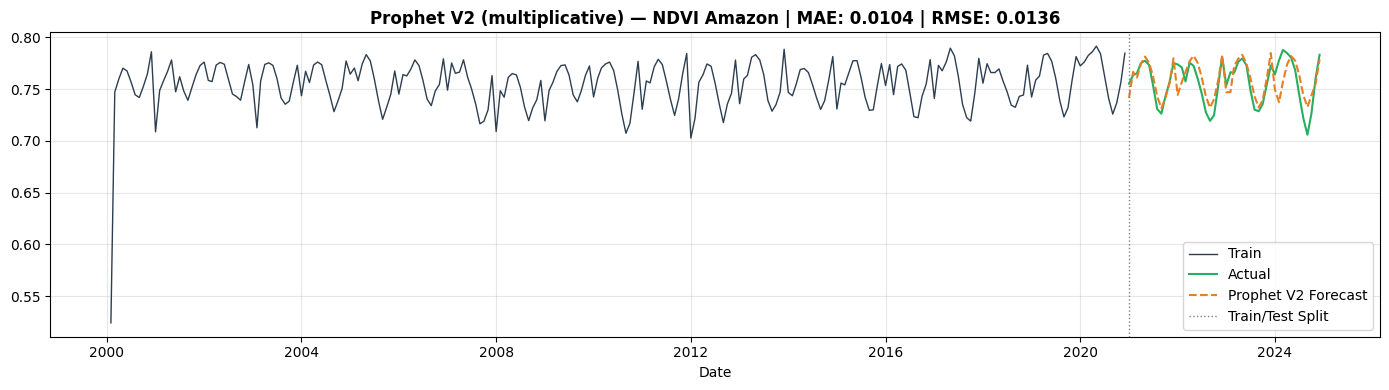

03:08:09 - cmdstanpy - INFO - Chain [1] start processing
03:08:09 - cmdstanpy - INFO - Chain [1] done processing



Fitting Prophet V2 for NDVI Sahel...

  Tuning Prophet for NDVI Sahel...


  0%|          | 0/10 [00:00<?, ?it/s]

03:08:09 - cmdstanpy - INFO - Chain [1] start processing
03:08:09 - cmdstanpy - INFO - Chain [1] done processing
03:08:09 - cmdstanpy - INFO - Chain [1] start processing
03:08:09 - cmdstanpy - INFO - Chain [1] done processing
03:08:09 - cmdstanpy - INFO - Chain [1] start processing
03:08:09 - cmdstanpy - INFO - Chain [1] done processing
03:08:09 - cmdstanpy - INFO - Chain [1] start processing
03:08:10 - cmdstanpy - INFO - Chain [1] done processing
03:08:10 - cmdstanpy - INFO - Chain [1] start processing
03:08:10 - cmdstanpy - INFO - Chain [1] done processing
03:08:10 - cmdstanpy - INFO - Chain [1] start processing
03:08:10 - cmdstanpy - INFO - Chain [1] done processing
03:08:10 - cmdstanpy - INFO - Chain [1] start processing
03:08:10 - cmdstanpy - INFO - Chain [1] done processing
03:08:10 - cmdstanpy - INFO - Chain [1] start processing
03:08:10 - cmdstanpy - INFO - Chain [1] done processing
03:08:10 - cmdstanpy - INFO - Chain [1] start processing
03:08:11 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

03:08:43 - cmdstanpy - INFO - Chain [1] start processing
03:08:43 - cmdstanpy - INFO - Chain [1] done processing
03:08:43 - cmdstanpy - INFO - Chain [1] start processing
03:08:43 - cmdstanpy - INFO - Chain [1] done processing
03:08:43 - cmdstanpy - INFO - Chain [1] start processing
03:08:43 - cmdstanpy - INFO - Chain [1] done processing
03:08:43 - cmdstanpy - INFO - Chain [1] start processing
03:08:43 - cmdstanpy - INFO - Chain [1] done processing
03:08:44 - cmdstanpy - INFO - Chain [1] start processing
03:08:44 - cmdstanpy - INFO - Chain [1] done processing
03:08:44 - cmdstanpy - INFO - Chain [1] start processing
03:08:44 - cmdstanpy - INFO - Chain [1] done processing
03:08:44 - cmdstanpy - INFO - Chain [1] start processing
03:08:44 - cmdstanpy - INFO - Chain [1] done processing
03:08:44 - cmdstanpy - INFO - Chain [1] start processing
03:08:44 - cmdstanpy - INFO - Chain [1] done processing
03:08:45 - cmdstanpy - INFO - Chain [1] start processing
03:08:45 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/10 [00:00<?, ?it/s]

03:08:45 - cmdstanpy - INFO - Chain [1] start processing
03:08:46 - cmdstanpy - INFO - Chain [1] done processing
03:08:46 - cmdstanpy - INFO - Chain [1] start processing
03:08:46 - cmdstanpy - INFO - Chain [1] done processing
03:08:46 - cmdstanpy - INFO - Chain [1] start processing
03:08:46 - cmdstanpy - INFO - Chain [1] done processing
03:08:46 - cmdstanpy - INFO - Chain [1] start processing
03:08:46 - cmdstanpy - INFO - Chain [1] done processing
03:08:46 - cmdstanpy - INFO - Chain [1] start processing
03:08:46 - cmdstanpy - INFO - Chain [1] done processing
03:08:47 - cmdstanpy - INFO - Chain [1] start processing
03:08:47 - cmdstanpy - INFO - Chain [1] done processing
03:08:47 - cmdstanpy - INFO - Chain [1] start processing
03:08:47 - cmdstanpy - INFO - Chain [1] done processing
03:08:47 - cmdstanpy - INFO - Chain [1] start processing
03:08:47 - cmdstanpy - INFO - Chain [1] done processing
03:08:47 - cmdstanpy - INFO - Chain [1] start processing
03:08:47 - cmdstanpy - INFO - Chain [1]

  Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0} | CV MAE: 0.0054


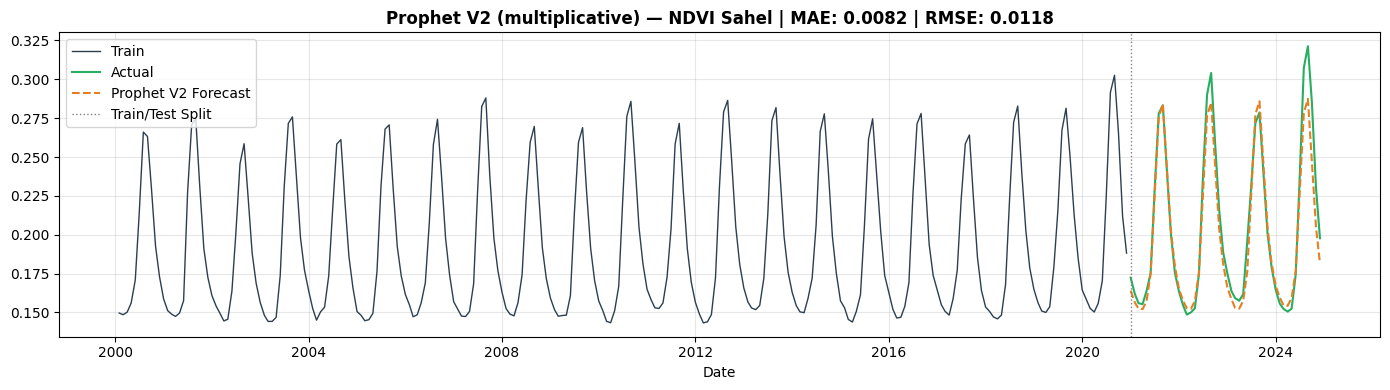

03:08:49 - cmdstanpy - INFO - Chain [1] start processing
03:08:49 - cmdstanpy - INFO - Chain [1] done processing



Fitting Prophet V2 for SST North Atlantic...

  Tuning Prophet for SST North Atlantic...


  0%|          | 0/10 [00:00<?, ?it/s]

03:08:49 - cmdstanpy - INFO - Chain [1] start processing
03:08:49 - cmdstanpy - INFO - Chain [1] done processing
03:08:49 - cmdstanpy - INFO - Chain [1] start processing
03:08:49 - cmdstanpy - INFO - Chain [1] done processing
03:08:49 - cmdstanpy - INFO - Chain [1] start processing
03:08:49 - cmdstanpy - INFO - Chain [1] done processing
03:08:49 - cmdstanpy - INFO - Chain [1] start processing
03:08:49 - cmdstanpy - INFO - Chain [1] done processing
03:08:50 - cmdstanpy - INFO - Chain [1] start processing
03:08:50 - cmdstanpy - INFO - Chain [1] done processing
03:08:50 - cmdstanpy - INFO - Chain [1] start processing
03:08:50 - cmdstanpy - INFO - Chain [1] done processing
03:08:50 - cmdstanpy - INFO - Chain [1] start processing
03:08:50 - cmdstanpy - INFO - Chain [1] done processing
03:08:50 - cmdstanpy - INFO - Chain [1] start processing
03:08:50 - cmdstanpy - INFO - Chain [1] done processing
03:08:50 - cmdstanpy - INFO - Chain [1] start processing
03:08:51 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

03:09:22 - cmdstanpy - INFO - Chain [1] start processing
03:09:22 - cmdstanpy - INFO - Chain [1] done processing
03:09:22 - cmdstanpy - INFO - Chain [1] start processing
03:09:22 - cmdstanpy - INFO - Chain [1] done processing
03:09:22 - cmdstanpy - INFO - Chain [1] start processing
03:09:22 - cmdstanpy - INFO - Chain [1] done processing
03:09:22 - cmdstanpy - INFO - Chain [1] start processing
03:09:23 - cmdstanpy - INFO - Chain [1] done processing
03:09:23 - cmdstanpy - INFO - Chain [1] start processing
03:09:23 - cmdstanpy - INFO - Chain [1] done processing
03:09:23 - cmdstanpy - INFO - Chain [1] start processing
03:09:23 - cmdstanpy - INFO - Chain [1] done processing
03:09:23 - cmdstanpy - INFO - Chain [1] start processing
03:09:23 - cmdstanpy - INFO - Chain [1] done processing
03:09:23 - cmdstanpy - INFO - Chain [1] start processing
03:09:24 - cmdstanpy - INFO - Chain [1] done processing
03:09:24 - cmdstanpy - INFO - Chain [1] start processing
03:09:24 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/10 [00:00<?, ?it/s]

03:09:25 - cmdstanpy - INFO - Chain [1] start processing
03:09:25 - cmdstanpy - INFO - Chain [1] done processing
03:09:25 - cmdstanpy - INFO - Chain [1] start processing
03:09:25 - cmdstanpy - INFO - Chain [1] done processing
03:09:25 - cmdstanpy - INFO - Chain [1] start processing
03:09:25 - cmdstanpy - INFO - Chain [1] done processing
03:09:25 - cmdstanpy - INFO - Chain [1] start processing
03:09:25 - cmdstanpy - INFO - Chain [1] done processing
03:09:25 - cmdstanpy - INFO - Chain [1] start processing
03:09:26 - cmdstanpy - INFO - Chain [1] done processing
03:09:26 - cmdstanpy - INFO - Chain [1] start processing
03:09:26 - cmdstanpy - INFO - Chain [1] done processing
03:09:26 - cmdstanpy - INFO - Chain [1] start processing
03:09:26 - cmdstanpy - INFO - Chain [1] done processing
03:09:26 - cmdstanpy - INFO - Chain [1] start processing
03:09:26 - cmdstanpy - INFO - Chain [1] done processing
03:09:26 - cmdstanpy - INFO - Chain [1] start processing
03:09:27 - cmdstanpy - INFO - Chain [1]

  Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0} | CV MAE: 0.2149


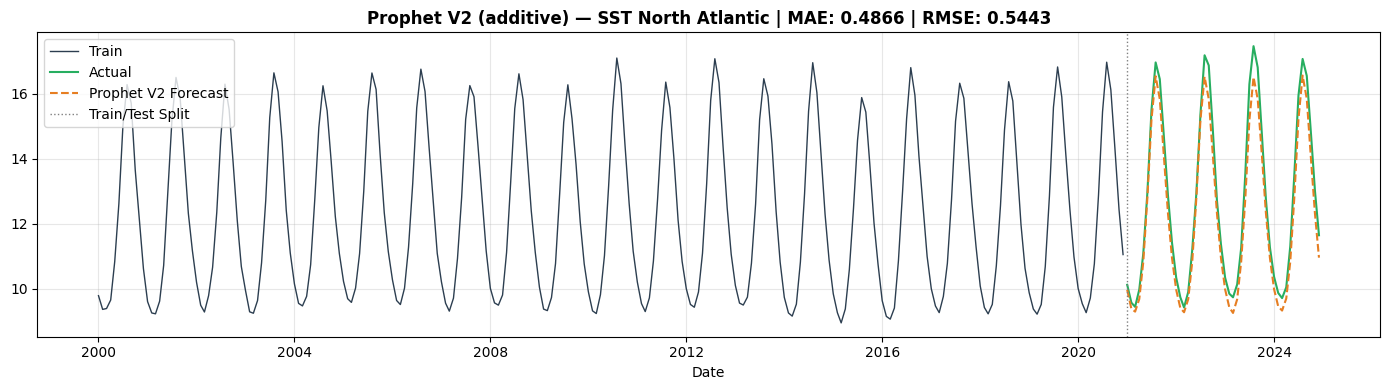

03:09:28 - cmdstanpy - INFO - Chain [1] start processing
03:09:28 - cmdstanpy - INFO - Chain [1] done processing



Fitting Prophet V2 for SST Indian Ocean...

  Tuning Prophet for SST Indian Ocean...


  0%|          | 0/10 [00:00<?, ?it/s]

03:09:28 - cmdstanpy - INFO - Chain [1] start processing
03:09:28 - cmdstanpy - INFO - Chain [1] done processing
03:09:28 - cmdstanpy - INFO - Chain [1] start processing
03:09:28 - cmdstanpy - INFO - Chain [1] done processing
03:09:28 - cmdstanpy - INFO - Chain [1] start processing
03:09:28 - cmdstanpy - INFO - Chain [1] done processing
03:09:28 - cmdstanpy - INFO - Chain [1] start processing
03:09:28 - cmdstanpy - INFO - Chain [1] done processing
03:09:29 - cmdstanpy - INFO - Chain [1] start processing
03:09:29 - cmdstanpy - INFO - Chain [1] done processing
03:09:29 - cmdstanpy - INFO - Chain [1] start processing
03:09:29 - cmdstanpy - INFO - Chain [1] done processing
03:09:29 - cmdstanpy - INFO - Chain [1] start processing
03:09:29 - cmdstanpy - INFO - Chain [1] done processing
03:09:29 - cmdstanpy - INFO - Chain [1] start processing
03:09:29 - cmdstanpy - INFO - Chain [1] done processing
03:09:29 - cmdstanpy - INFO - Chain [1] start processing
03:09:29 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

03:10:02 - cmdstanpy - INFO - Chain [1] start processing
03:10:02 - cmdstanpy - INFO - Chain [1] done processing
03:10:02 - cmdstanpy - INFO - Chain [1] start processing
03:10:02 - cmdstanpy - INFO - Chain [1] done processing
03:10:03 - cmdstanpy - INFO - Chain [1] start processing
03:10:03 - cmdstanpy - INFO - Chain [1] done processing
03:10:03 - cmdstanpy - INFO - Chain [1] start processing
03:10:03 - cmdstanpy - INFO - Chain [1] done processing
03:10:03 - cmdstanpy - INFO - Chain [1] start processing
03:10:03 - cmdstanpy - INFO - Chain [1] done processing
03:10:03 - cmdstanpy - INFO - Chain [1] start processing
03:10:03 - cmdstanpy - INFO - Chain [1] done processing
03:10:04 - cmdstanpy - INFO - Chain [1] start processing
03:10:04 - cmdstanpy - INFO - Chain [1] done processing
03:10:04 - cmdstanpy - INFO - Chain [1] start processing
03:10:04 - cmdstanpy - INFO - Chain [1] done processing
03:10:04 - cmdstanpy - INFO - Chain [1] start processing
03:10:04 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/10 [00:00<?, ?it/s]

03:10:05 - cmdstanpy - INFO - Chain [1] start processing
03:10:05 - cmdstanpy - INFO - Chain [1] done processing
03:10:05 - cmdstanpy - INFO - Chain [1] start processing
03:10:05 - cmdstanpy - INFO - Chain [1] done processing
03:10:05 - cmdstanpy - INFO - Chain [1] start processing
03:10:06 - cmdstanpy - INFO - Chain [1] done processing
03:10:06 - cmdstanpy - INFO - Chain [1] start processing
03:10:06 - cmdstanpy - INFO - Chain [1] done processing
03:10:06 - cmdstanpy - INFO - Chain [1] start processing
03:10:06 - cmdstanpy - INFO - Chain [1] done processing
03:10:06 - cmdstanpy - INFO - Chain [1] start processing
03:10:06 - cmdstanpy - INFO - Chain [1] done processing
03:10:07 - cmdstanpy - INFO - Chain [1] start processing
03:10:07 - cmdstanpy - INFO - Chain [1] done processing
03:10:07 - cmdstanpy - INFO - Chain [1] start processing
03:10:07 - cmdstanpy - INFO - Chain [1] done processing
03:10:07 - cmdstanpy - INFO - Chain [1] start processing
03:10:07 - cmdstanpy - INFO - Chain [1]

  Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0} | CV MAE: 0.2511


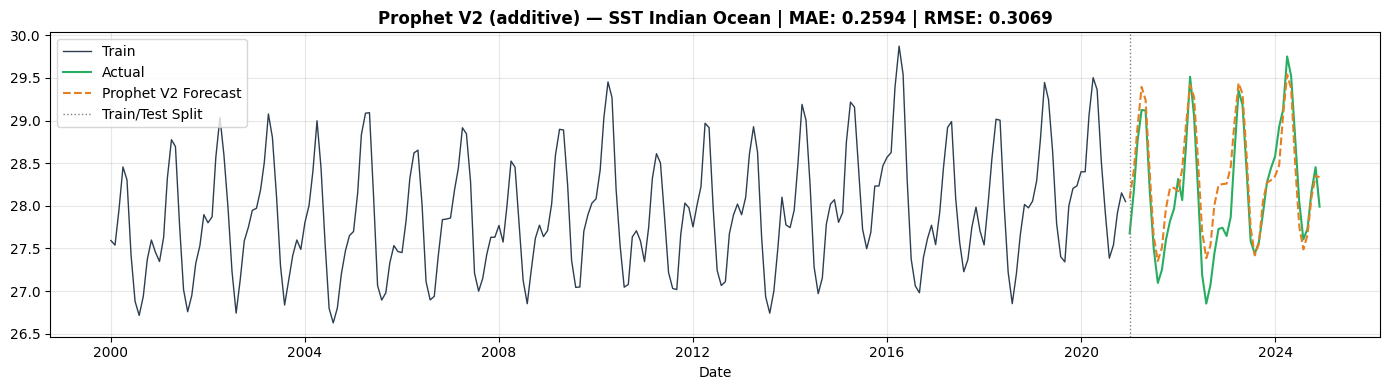


=== Prophet V2 Results ===
            series seasonality_mode  changepoint_prior_scale  seasonality_prior_scale    MAE   RMSE
       NDVI Amazon   multiplicative                     0.01                     20.0 0.0104 0.0136
        NDVI Sahel   multiplicative                     0.01                      1.0 0.0082 0.0118
SST North Atlantic         additive                     0.01                     10.0 0.4866 0.5443
  SST Indian Ocean         additive                     0.01                     10.0 0.2594 0.3069


In [3]:
# ============================================================
# Prophet V2 — Tuned hyperparameters via cross-validation
# Improvements over V1 (default settings):
#   - changepoint_prior_scale tuned (controls trend flexibility)
#   - seasonality_prior_scale tuned (controls seasonal strength)
#   - changepoint_range=0.95 (allows changepoints closer to end)
#   - multiplicative seasonality tested for NDVI series
#     (amplitude grows with level — Sahel vegetation trend)
#   - cross_validation used to select best prior scales
# Reference: Taylor & Letham (2018) Am. Statistician 72(1)
# ============================================================

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

def tune_prophet(train, value_col, series_name, seasonality_mode='additive'):
    """Use Prophet cross-validation to find best hyperparameters."""
    print(f"\n  Tuning Prophet for {series_name}...")
    
    train_prophet = train[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'})
    
    best_mae = float('inf')
    best_params = {}
    
    # Parameter grid — focused search around V1 defaults
    changepoint_scales = [0.01, 0.05, 0.1, 0.3]
    seasonality_scales = [1.0, 5.0, 10.0, 20.0]
    
    for cp_scale in changepoint_scales:
        for s_scale in seasonality_scales:
            try:
                m = Prophet(
                    changepoint_prior_scale=cp_scale,
                    seasonality_prior_scale=s_scale,
                    seasonality_mode=seasonality_mode,
                    yearly_seasonality=True,
                    weekly_seasonality=False,
                    daily_seasonality=False,
                    changepoint_range=0.95
                )
                m.fit(train_prophet)
                
                # Cross-validation: 180-day horizon, 365-day initial, 180-day period
                df_cv = cross_validation(
                    m,
                    initial='3650 days',   # ~10 years training
                    period='365 days',     # evaluate every year
                    horizon='365 days',    # 1-year forecast horizon
                    parallel=None
                )
                df_p = performance_metrics(df_cv, rolling_window=1)
                mae = df_p['mae'].mean()
                
                if mae < best_mae:
                    best_mae = mae
                    best_params = {
                        'changepoint_prior_scale': cp_scale,
                        'seasonality_prior_scale': s_scale
                    }
            except:
                continue
    
    print(f"  Best params: {best_params} | CV MAE: {best_mae:.4f}")
    return best_params

def run_prophet_v2(train, test, value_col, series_name, seasonality_mode='additive'):
    print(f"\nFitting Prophet V2 for {series_name}...")
    
    # Tune first
    best_params = tune_prophet(train, value_col, series_name, seasonality_mode)
    
    train_prophet = train[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'})
    test_prophet = test[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'})
    
    # Fit with best params
    model = Prophet(
        changepoint_prior_scale=best_params['changepoint_prior_scale'],
        seasonality_prior_scale=best_params['seasonality_prior_scale'],
        seasonality_mode=seasonality_mode,
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_range=0.95
    )
    model.fit(train_prophet)
    
    # Forecast
    future = model.make_future_dataframe(periods=len(test), freq='MS')
    forecast = model.predict(future)
    forecast_test = forecast.tail(len(test))['yhat'].values
    actual = test[value_col].values
    
    # Metrics
    mae = mean_absolute_error(actual, forecast_test)
    rmse = np.sqrt(mean_squared_error(actual, forecast_test))
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['date'], train[value_col],
            color='#2c3e50', linewidth=1, label='Train')
    ax.plot(test['date'], actual,
            color='#27ae60', linewidth=1.5, label='Actual')
    ax.plot(test['date'], forecast_test,
            color='#e67e22', linewidth=1.5, linestyle='--',
            label=f'Prophet V2 Forecast')
    ax.axvline(x=test['date'].iloc[0], color='grey',
               linestyle=':', linewidth=1, label='Train/Test Split')
    ax.set_title(f'Prophet V2 ({seasonality_mode}) — {series_name} | MAE: {mae:.4f} | RMSE: {rmse:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    filename = f"fig_prophet_v2_{series_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    return {
        'series': series_name,
        'seasonality_mode': seasonality_mode,
        'changepoint_prior_scale': best_params['changepoint_prior_scale'],
        'seasonality_prior_scale': best_params['seasonality_prior_scale'],
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4)
    }

# Run V2 — NDVI series use multiplicative (amplitude varies with level)
# SST series use additive (amplitude stable)
results_prophet_v2 = []

results_prophet_v2.append(run_prophet_v2(
    ndvi_amazon_train, ndvi_amazon_test,
    'ndvi_mean', 'NDVI Amazon', seasonality_mode='multiplicative'))

results_prophet_v2.append(run_prophet_v2(
    ndvi_sahel_train, ndvi_sahel_test,
    'ndvi_mean', 'NDVI Sahel', seasonality_mode='multiplicative'))

results_prophet_v2.append(run_prophet_v2(
    sst_atlantic_train, sst_atlantic_test,
    'sst_mean', 'SST North Atlantic', seasonality_mode='additive'))

results_prophet_v2.append(run_prophet_v2(
    sst_indian_train, sst_indian_test,
    'sst_mean', 'SST Indian Ocean', seasonality_mode='additive'))

# Results table
results_prophet_v2_df = pd.DataFrame(results_prophet_v2)
print("\n=== Prophet V2 Results ===")
print(results_prophet_v2_df.to_string(index=False))